In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.7 MB/s eta 0:00:00


In [3]:
from faker import Faker
fake = Faker()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker
import random

from google.colab import files

In [5]:
fake = Faker()

rows = 300

regions = ['North','South','East','West']
categories = ['Electronics','Fashion','Books','Home & Kitchen']
payments = ['UPI','Credit Card','Debit Card','COD']

data = []

for i in range(rows):

    qty = random.randint(1,5)
    price = random.randint(500,5000)

    sales = qty * price
    cost = sales * random.uniform(0.5,0.8)
    profit = sales - cost

    data.append([
        f'O{i+1001}',
        fake.name(),
        fake.date_between(start_date='-1y', end_date='today'),
        random.choice(regions),
        random.choice(categories),
        qty,
        price,
        round(sales,2),
        round(cost,2),
        round(profit,2),
        random.choice(payments)
    ])

df = pd.DataFrame(data, columns=[
    'Order_ID',
    'Customer_Name',
    'Order_Date',
    'Region',
    'Category',
    'Quantity',
    'Unit_Price',
    'Sales_Amount',
    'Cost_Amount',
    'Profit_Amount',
    'Payment_Method'
])

df.head()

,Order_ID,Customer_Name,Order_Date,Region,Category,Quantity,Unit_Price,Sales_Amount,Cost_Amount,Profit_Amount,Payment_Method
0,O1001,Emily Erickson,2026-04-24,South,Home & Kitchen,5,3782,18910,10658.80,8251.20,COD
1,O1002,Kimberly Oconnell,2026-03-21,South,Electronics,2,617,1234,940.86,293.14,Debit Card
2,O1003,Diane Goodwin,2025-06-23,West,Electronics,5,1427,7135,3582.79,3552.21,UPI
3,O1004,Randy Curtis,2026-02-12,West,Books,5,2881,14405,8839.76,5565.24,COD
4,O1005,Christopher Huber,2026-02-24,North,Home & Kitchen,5,2671,13355,9627.57,3727.43,Debit Card


In [6]:
df.to_csv('Ecommerce_Sales_Data.csv', index=False)

files.download('Ecommerce_Sales_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
df.drop_duplicates(inplace=True)

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print(df.isnull().sum())

Order_ID          0
Customer_Name     0
Order_Date        0
Region            0
Category          0
Quantity          0
Unit_Price        0
Sales_Amount      0
Cost_Amount       0
Profit_Amount     0
Payment_Method    0
dtype: int64


In [8]:
total_sales = df['Sales_Amount'].sum()

total_profit = df['Profit_Amount'].sum()

total_orders = df['Order_ID'].nunique()

profit_margin = (total_profit/total_sales)*100

print("Total Sales =", round(total_sales,2))
print("Total Profit =", round(total_profit,2))
print("Total Orders =", total_orders)
print("Profit Margin =", round(profit_margin,2),"%")

Total Sales = 2336547
Total Profit = 828484.6
Total Orders = 300
Profit Margin = 35.46 %


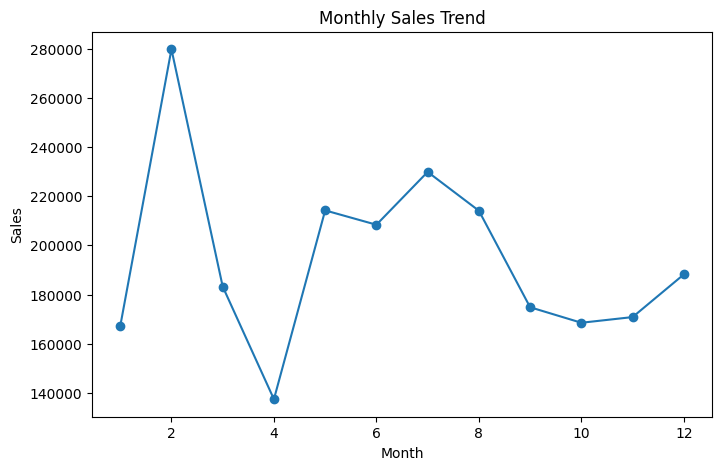

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
df['Month'] = df['Order_Date'].dt.month

monthly_sales = df.groupby('Month')['Sales_Amount'].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("Sales_Trend.png")

plt.show()

files.download("Sales_Trend.png")

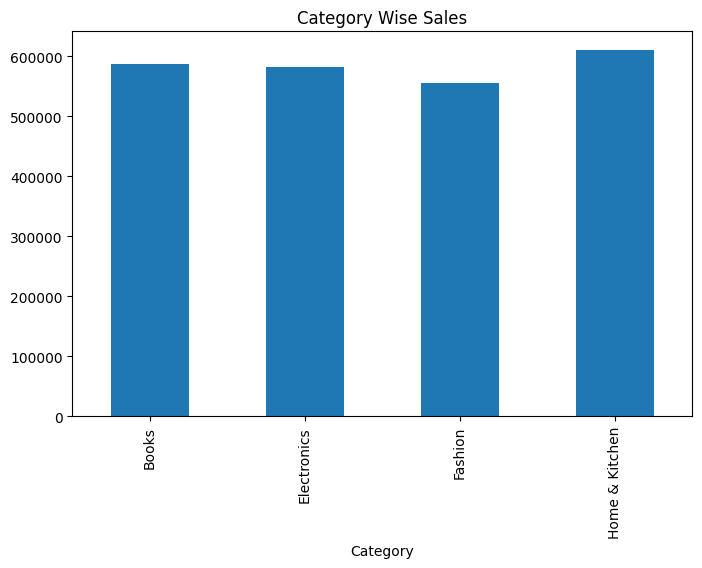

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
category_sales = df.groupby('Category')['Sales_Amount'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Category Wise Sales")

plt.savefig("Category_Sales.png")

plt.show()

files.download("Category_Sales.png")

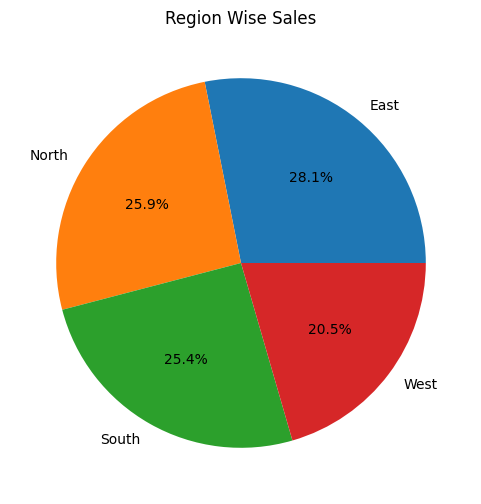

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()

plt.figure(figsize=(6,6))

plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%')

plt.title("Region Wise Sales")

plt.savefig("Region_Sales.png")

plt.show()

files.download("Region_Sales.png")

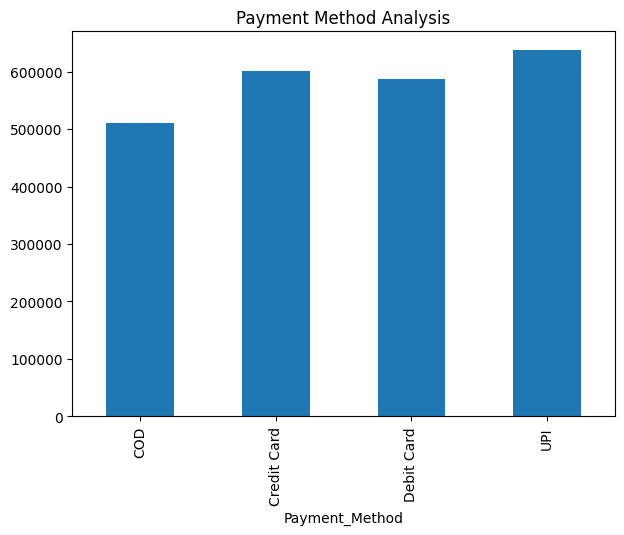

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
payment_sales = df.groupby('Payment_Method')['Sales_Amount'].sum()

plt.figure(figsize=(7,5))

payment_sales.plot(kind='bar')

plt.title("Payment Method Analysis")

plt.savefig("Payment_Method_Analysis.png")

plt.show()

files.download("Payment_Method_Analysis.png")

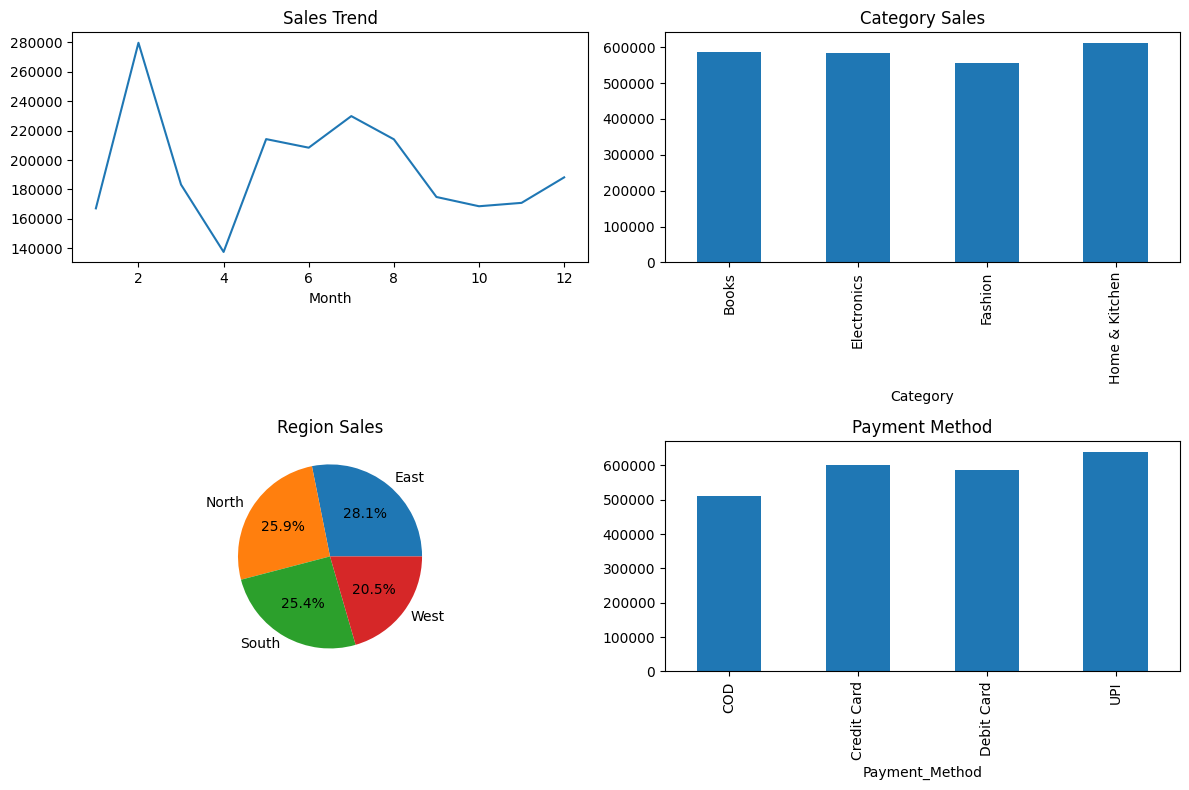

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

monthly_sales.plot(ax=ax[0,0])
ax[0,0].set_title("Sales Trend")

category_sales.plot(kind='bar', ax=ax[0,1])
ax[0,1].set_title("Category Sales")

region_sales.plot(kind='pie', ax=ax[1,0], autopct='%1.1f%%')
ax[1,0].set_ylabel("")
ax[1,0].set_title("Region Sales")

payment_sales.plot(kind='bar', ax=ax[1,1])
ax[1,1].set_title("Payment Method")

plt.tight_layout()

plt.savefig("Ecommerce_Dashboard.png")

plt.show()

files.download("Ecommerce_Dashboard.png")